# ENSF 444 Project - Airbnb Price Prediction

## Group Members
- Faris Janjua (30154612)
- Jaden Chow (30173676)
- Muhammad Aun Raza (30172183)

## 1. Problem Overview
This project focuses on the problem of predicting the nightly price of Airbnb listings for the proposed client, StaySmart Hosting Solutions. Setting an appropriate price is challenging because listing value depends on many factors, including location, property type, room type, host characteristics, review scores, amenities, and availability. Hosts who set prices too high risk losing bookings, while hosts who set prices too low may lose revenue. To address this issue, the project uses the Vancouver Inside Airbnb detailed listings dataset to build regression models that estimate nightly prices from listing features. By comparing Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor, the project aims to determine which model provides the most accurate and practical pricing recommendations for Airbnb hosts.

## 2. Dataset Overview

In this project, we use the Vancouver Inside Airbnb detailed listings dataset. This dataset contains information about Airbnb listings, hosts, availability, reviews, and pricing. It is a structured tabular dataset with a mixture of numerical, categorical, boolean, text, and date-based features. Our target variable is the nightly listing price.## 2. Dataset Overview

In [ ]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
DATA_PATH = "data/listings.csv.gz"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "Dataset not found. Make sure listings.csv.gz is inside the top-level data folder."
    )

df = pd.read_csv(DATA_PATH, compression="gzip")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (5685, 79)


In [4]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13188,https://www.airbnb.com/rooms/13188,20251117002517,2025-11-17,city scrape,Garden level studio in ideal loc.,Garden level studio suite with garden patio - ...,The uber hip Main street area is a short walk ...,https://a0.muscache.com/pictures/8408188/e1af6...,51466,...,4.93,4.91,4.81,Municipal registration number: 25-156058<br />...,f,1,1,0,0,1.99
1,13358,https://www.airbnb.com/rooms/13358,20251117002517,2025-11-17,city scrape,Downtown Boutique Suite,The iconic Electra Building is a Landmark!<br ...,2 blocks away from the shopping area of Robson...,https://a0.muscache.com/pictures/hosting/Hosti...,52116,...,4.81,4.91,4.67,Municipal registration number: 25-157257<br />...,f,1,1,0,0,3.11
2,16611,https://www.airbnb.com/rooms/16611,20251117002517,2025-11-17,previous scrape,"1 block to skytrain station, shops,restaurant,...","My place is close to bank, coffee shops, groce...",Next block to Commercial Drive which has many ...,https://a0.muscache.com/pictures/82101/7127b63...,58512,...,4.33,5.00,3.67,NaN,f,5,5,0,0,0.03
3,18270,https://www.airbnb.com/rooms/18270,20251117002517,2025-11-17,city scrape,private rm in clean central 2BR apt,I have a bright furnished 2 bedroom suite on a...,"Lots of restaurants, coffee shops.<br />Easy a...",https://a0.muscache.com/pictures/108520241/aec...,70437,...,4.73,4.69,4.49,NaN,f,1,0,1,0,0.66
4,18589,https://www.airbnb.com/rooms/18589,20251117002517,2025-11-17,city scrape,Commercial Drive B&B,"As hosts, we are welcoming you into our home, ...",Lots of restaurants and boutiques just outside...,https://a0.muscache.com/pictures/dd3ca406-cb74...,71508,...,5.00,4.93,4.95,Municipal registration number: 25-155972<br />...,f,1,0,1,0,3.60


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5685 entries, 0 to 5684
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            5685 non-null   int64  
 1   listing_url                                   5685 non-null   object 
 2   scrape_id                                     5685 non-null   int64  
 3   last_scraped                                  5685 non-null   object 
 4   source                                        5685 non-null   object 
 5   name                                          5685 non-null   object 
 6   description                                   5631 non-null   object 
 7   neighborhood_overview                         2785 non-null   object 
 8   picture_url                                   5685 non-null   object 
 9   host_id                                       5685 non-null   i

In [6]:
df.isnull().sum().sort_values(ascending=False).head(20)

calendar_updated                5685
neighbourhood_group_cleansed    5685
neighbourhood                   2900
neighborhood_overview           2900
host_about                      2838
host_location                   1343
license                         1321
host_response_time              1173
host_response_rate              1173
bathrooms                       1064
estimated_revenue_l365d         1064
price                           1064
beds                            1063
review_scores_checkin            833
last_review                      833
review_scores_rating             833
review_scores_accuracy           833
review_scores_cleanliness        833
reviews_per_month                833
first_review                     833
dtype: int64

In [7]:
df.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

## 3. Data Preprocessing

Before training our models, we need to clean the dataset and prepare it for machine learning. This includes cleaning the target variable, selecting useful features, handling missing values, and preparing categorical and numerical data for preprocessing.

In [8]:
# Make a copy so the original dataframe remains unchanged
df_clean = df.copy()

# Clean the price column by removing dollar signs and commas
df_clean["price"] = (
    df_clean["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df_clean["price"] = pd.to_numeric(df_clean["price"], errors="coerce")

print("Price column cleaned.")
df_clean["price"].head()

Price column cleaned.


0    136.0
1    188.0
2      NaN
3     47.0
4    123.0
Name: price, dtype: float64

In [9]:
# Drop rows where the target price is missing
df_clean = df_clean.dropna(subset=["price"])

print("Shape after removing rows with missing target values:", df_clean.shape)

Shape after removing rows with missing target values: (4621, 79)


In [10]:
# Candidate features based on our proposal
candidate_features = [
    "neighbourhood_cleansed",
    "property_type",
    "room_type",
    "accommodates",
    "bathrooms",
    "bathrooms_text",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_30",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "host_is_superhost",
    "instant_bookable"
]

# Keep only features that actually exist in the dataset
selected_features = [col for col in candidate_features if col in df_clean.columns]

print("Selected features:")
print(selected_features)

Selected features:
['neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'minimum_nights', 'availability_30', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'host_is_superhost', 'instant_bookable']


In [11]:
# Keep only selected features plus target
df_model = df_clean[selected_features + ["price"]].copy()

print("Modeling dataframe shape:", df_model.shape)
df_model.head()

Modeling dataframe shape: (4621, 16)


,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,minimum_nights,availability_30,availability_365,number_of_reviews,review_scores_rating,host_is_superhost,instant_bookable,price
0,Riley Park,Entire guest suite,Entire home/apt,4,1.0,1 bath,0.0,2.0,2,0,170,381,4.85,t,f,136.0
1,Downtown,Entire condo,Entire home/apt,2,1.0,1 bath,1.0,1.0,2,14,178,584,4.71,t,f,188.0
3,Mount Pleasant,Private room in condo,Private room,2,1.0,1 shared bath,1.0,1.0,90,21,260,118,4.54,f,f,47.0
4,Grandview-Woodland,Private room in home,Private room,2,1.0,1 private bath,1.0,1.0,1,28,99,634,4.98,t,f,123.0
5,West End,Private room in home,Private room,2,1.0,1 private bath,1.0,1.0,90,30,365,131,4.56,f,f,75.0


In [12]:
# Separate features by type
numeric_features = df_model[selected_features].select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df_model[selected_features].select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'availability_30', 'availability_365', 'number_of_reviews', 'review_scores_rating']
Categorical features: ['neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'host_is_superhost', 'instant_bookable']


In [13]:
# Preprocessing for numerical columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both into one preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 4. Feature Selection and Train/Test Split

After cleaning the dataset and selecting the most relevant features, we split the data into input features and target values. We then create training and testing sets so that model performance can be evaluated fairly on unseen data.

In [14]:
X = df_model[selected_features]
y = df_model["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4621, 15)
y shape: (4621,)


In [15]:
X = df_model[selected_features]
y = df_model["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4621, 15)
y shape: (4621,)


## 5. Model 1 - Linear Regression

In [21]:
# variable initialization

from sklearn.model_selection import train_test_split

X = df_model[selected_features]
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3696, 15)
X_test shape: (925, 15)
y_train shape: (3696,)
y_test shape: (925,)


In [22]:
# preprocessing 

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_linear = ColumnTransformer(transformers=[
    ("num", numeric_transformer_linear, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [23]:
# linear regression model 

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_linear),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

Linear Regression Results
MAE: 72.48542461885984
RMSE: 172.38031500164647
R2: 0.4491264296396593


## 6. Model 2 - Random Forest Regressor

In [24]:
# preprocess the features for tree-based models (no scaling)

from sklearn.ensemble import RandomForestRegressor

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("num", numeric_transformer_tree, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [25]:
# random forest model 

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results
MAE: 67.67563574488021
RMSE: 158.22773761451612
R2: 0.5358676568492089


## 7. Model 3 - Gradient Boosting Regressor


In [26]:
# gradient boosting model

from sklearn.ensemble import GradientBoostingRegressor

gbr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
])

gbr_pipeline.fit(X_train, y_train)

y_pred_gbr = gbr_pipeline.predict(X_test)

gbr_mae = mean_absolute_error(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
gbr_r2 = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Results")
print("MAE:", gbr_mae)
print("RMSE:", gbr_rmse)
print("R2:", gbr_r2)

Gradient Boosting Results
MAE: 64.97048306521765
RMSE: 141.01333580961122
R2: 0.6313646584977874


We compared three regression models for predicting Airbnb nightly prices:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

We evaluated the models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² on the held-out test set. Lower MAE and RMSE indicate lower prediction error, while a higher R² indicates better overall fit.

## 8. Model Comparison

In [27]:
# comparison table

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [linear_mae, rf_mae, gbr_mae],
    "RMSE": [linear_rmse, rf_rmse, gbr_rmse],
    "R2": [linear_r2, rf_r2, gbr_r2]
})

results = results.sort_values(by="R2", ascending=False)
results

,Model,MAE,RMSE,R2
2,Gradient Boosting,64.970483,141.013336,0.631365
1,Random Forest,67.675636,158.227738,0.535868
0,Linear Regression,72.485425,172.380315,0.449126


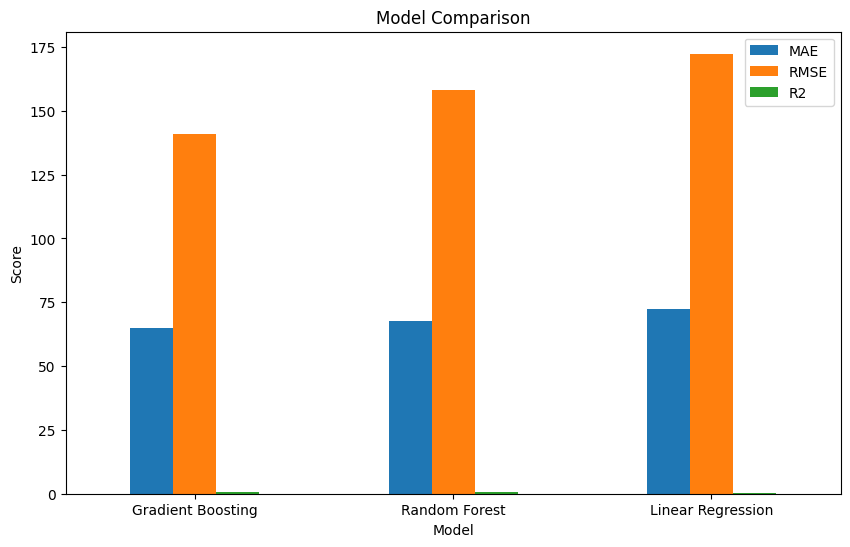

In [28]:
# bar chart
results_plot = results.set_index("Model")

results_plot[["MAE", "RMSE", "R2"]].plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## 9. Results Visualization
The results were visualized using both a comparison table and a bar chart showing the performance of the three regression models: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. We evaluated each model using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and 
𝑅
2
R
2
, since these metrics provide a clear picture of prediction quality from different angles. MAE shows the average absolute pricing error in dollars, RMSE places greater emphasis on large mistakes, and 
𝑅
2
R
2
 measures how much of the variation in listing price is explained by the model. This combination allowed us to compare the models in a way that is both technically meaningful and easy to interpret.

The visual comparison showed a clear ranking among the three models. Gradient Boosting performed best overall, achieving the lowest MAE of 64.97, the lowest RMSE of 141.01, and the highest 
𝑅
2
R
2
 of 0.6314. Random Forest placed second, with an MAE of 67.68, RMSE of 158.23, and 
𝑅
2
R
2
 of 0.5359. Linear Regression had the weakest results, with the highest MAE of 72.49, the highest RMSE of 172.38, and the lowest 
𝑅
2
R
2
 of 0.4491. The chart makes this pattern easy to observe at a glance and confirms that the more flexible nonlinear models outperformed the linear baseline.

This visualization is important because it connects the technical side of the project to the client’s real objective. For StaySmart Hosting Solutions, the most useful model is the one that produces the most accurate and consistent price estimates on unseen listings. Since Gradient Boosting had the strongest performance across all three metrics, the visual summary supports selecting it as the best model for the pricing recommendation task.

## 10. Interpretation of Results
The results show that predicting Airbnb prices is possible with reasonable accuracy, but it is also a fairly complex machine learning problem. Listing price is not determined by a single variable. Instead, it depends on interactions between location, property type, room type, size, host characteristics, review history, and booking-related features. Because of this, it makes sense that the nonlinear models performed better than Linear Regression. A linear model can only capture simpler relationships, while Airbnb pricing patterns are more likely to involve combinations of variables that affect price in more complicated ways.

Gradient Boosting produced the best results, with the lowest prediction errors and the highest explanatory power. Its MAE of about $64.97 means that, on average, its predictions were off by roughly sixty-five dollars per listing. Its RMSE of 141.01 shows that some larger errors still occurred, but fewer than with the other models. Its 
𝑅
2
R
2
 score of 0.6314 indicates that the model explained about 63% of the variation in Airbnb prices in the test set. For a real-world dataset with many pricing influences, this is a solid result and suggests that the model learned meaningful patterns from the available features.

Random Forest also performed reasonably well, but not as strongly as Gradient Boosting. It still outperformed Linear Regression by a noticeable margin, which reinforces the idea that nonlinear models are better suited for this problem. Linear Regression served its purpose as a baseline model, but its weaker MAE, RMSE, and 
𝑅
2
R
2
 values show that a simple linear relationship is not enough to model Airbnb pricing effectively in this dataset.

From a business point of view, these results suggest that machine learning can provide useful support for Airbnb hosts, but the model should be treated as a recommendation tool rather than a perfect pricing system. An average error of around sixty-five dollars is still meaningful, especially for lower-priced listings, so the model should not be used blindly. However, it can still help hosts avoid clearly unreasonable prices and offer a more informed starting point than pure guesswork. For StaySmart Hosting Solutions, this means the model has practical value as a decision-support system, especially if combined with human judgment and local market awareness.

Overall, the results are good enough to show that the project was successful. The best model captured a substantial portion of the variation in nightly prices and outperformed the baseline by a clear margin. While there is still room for improvement, the outcome supports the idea that machine learning can be used effectively to guide pricing decisions in the short-term rental market.

## 11. Ethical Considerations
This project is valuable because it addresses a realistic pricing problem for Airbnb hosts using machine learning. Since the model could influence real pricing decisions, it is important to consider how inaccurate or biased predictions might affect hosts and guests. The goal is not just to build a model for class, but to create a recommendation tool that could shape pricing in practice.

One ethical concern is bias in the data. Features such as neighbourhood may reflect existing market inequalities, so the model could learn pricing patterns that are profitable but not always fair. Another concern is over-reliance on predictions. A model can estimate prices from historical data, but it cannot fully capture unusual property features, sudden demand shifts, local events, or regulation changes. For that reason, its output should be treated as a recommendation rather than an automatic final decision.

There is also a privacy and responsible data-use concern. Host and listing data should be handled carefully, and unnecessary identifiers or irrelevant text fields should be removed during preprocessing. In addition, tools like this can have a broader social impact because optimizing short-term rental prices may indirectly support trends that worsen housing affordability in some areas.

To reduce these concerns, we would remove unnecessary identifying fields, evaluate model performance across different listing types and neighbourhoods, and clearly communicate that the model is a decision-support tool rather than a pricing authority. Comparing Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor also helps balance predictive performance with interpretability and transparency.

This discussion addresses the project requirement to consider ethical concerns in the final presentation.

## 12. Deviations from Proposal
Overall, the final project stayed close to the original proposal. We kept the same client, the same overall problem, the same Vancouver Inside Airbnb dataset, and the same three proposed models: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. The main goal also remained unchanged throughout the project: predicting nightly Airbnb prices using listing and host-related features in order to support pricing recommendations.

The main deviations were in implementation details rather than in the overall direction of the project. In the proposal, we discussed the possibility of using a wider range of dataset fields and potentially applying additional transformations such as a log transformation of the target if the price distribution appeared highly skewed. In the final project, we instead focused on a smaller, cleaner set of structured features that were most directly useful for regression, including neighbourhood, property type, room type, accommodates, bathrooms, bedrooms, beds, minimum nights, availability, number of reviews, review score, host superhost status, and instant bookable status. This made the workflow more manageable and reduced noise from text-heavy or identifier-based columns that were unlikely to improve prediction meaningfully in the scope of the course project.

Another deviation was that the final notebook emphasizes a straightforward model comparison rather than extensive model tuning or more advanced feature engineering. We used practical preprocessing steps such as removing rows with missing target values, imputing missing feature values, scaling numeric features for Linear Regression, and one-hot encoding categorical variables. This approach was appropriate for the course because it clearly demonstrates the machine learning workflow while still producing strong results. Rather than trying to build a highly optimized production system, the final project focused on building a solid and interpretable comparison between multiple models.

These changes did not alter the core purpose of the project. Instead, they improved the clarity and practicality of the final implementation. The final workflow still addressed the original problem effectively and allowed us to identify Gradient Boosting as the strongest model among the three tested approaches.

## 13. Conclusion
This project set out to solve a realistic business problem for the proposed client, StaySmart Hosting Solutions: estimating Airbnb nightly prices more accurately using machine learning. Using the Vancouver Inside Airbnb detailed listings dataset, we developed a regression workflow that cleaned the data, selected relevant features, handled missing values, encoded categorical variables, and compared three different models: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. This provided a clear comparison between a simple baseline model and two more flexible nonlinear methods.

The final results showed that Gradient Boosting performed best, achieving an MAE of 64.97, an RMSE of 141.01, and an 
𝑅
2
R
2
 of 0.6314. Random Forest also performed better than Linear Regression, but Gradient Boosting gave the strongest overall balance of lower error and better explanatory power. These findings suggest that Airbnb pricing depends on nonlinear relationships and interactions between features, which more advanced models are better able to capture.

From the client’s perspective, the project demonstrates that machine learning can be useful as a pricing recommendation tool. Although the model is not accurate enough to replace human decision-making entirely, it can provide a strong starting point and reduce the risk of obvious overpricing or underpricing. That makes it valuable for hosts who want more data-driven pricing support and for a company like StaySmart Hosting Solutions that aims to improve pricing decisions at scale.

In conclusion, the project successfully met its objective and satisfied the course requirements by comparing three regression models, including two nonlinear approaches, on a relevant real-world dataset. The results show that machine learning can provide meaningful insight into Airbnb pricing, and the performance of Gradient Boosting suggests that this approach has clear practical potential. With additional tuning, richer features, or more detailed market data, the system could likely be improved even further.